In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
pd.set_option('display.max_columns', None)

In [91]:
original_df = pd.read_csv('4.3_dataset_clean_v2.csv')

In [92]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   link              5589 non-null   object 
 1   address           5589 non-null   object 
 2   apartment_name    5589 non-null   object 
 3   sector            5589 non-null   object 
 4   price             5589 non-null   float64
 5   price_sqft        5589 non-null   float64
 6   super_area        5589 non-null   float64
 7   bedrooms          5589 non-null   int64  
 8   bathroom          5589 non-null   int64  
 9   balcony           5589 non-null   object 
 10  additional_rooms  3944 non-null   object 
 11  age_possession    5589 non-null   object 
 12  floor             5589 non-null   object 
 13  floor_num         5589 non-null   int64  
 14  total_floors      5589 non-null   int64  
 15  furnishing_type   5589 non-null   object 
 16  facing            5589 non-null   object 


In [93]:
df = original_df.drop(columns = ['link','address','additional_rooms','floor', 'num_parking','features'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   apartment_name   5589 non-null   object 
 1   sector           5589 non-null   object 
 2   price            5589 non-null   float64
 3   price_sqft       5589 non-null   float64
 4   super_area       5589 non-null   float64
 5   bedrooms         5589 non-null   int64  
 6   bathroom         5589 non-null   int64  
 7   balcony          5589 non-null   object 
 8   age_possession   5589 non-null   object 
 9   floor_num        5589 non-null   int64  
 10  total_floors     5589 non-null   int64  
 11  furnishing_type  5589 non-null   object 
 12  facing           5589 non-null   object 
 13  servant_room     5589 non-null   int64  
 14  study_room       5589 non-null   int64  
 15  pooja_room       5589 non-null   int64  
 16  store_room       5589 non-null   int64  
 17  luxury_score  

In [94]:
df.head()

,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
0,bharat residency,sector 39,0.70,5477.3,1278.0000,2,2,2,1 to 5 year old,0,4,Semifurnished,na,0,0,0,1,21,medium,1
1,gls arawali homes,sohna,0.38,5569.0,682.3526,2,2,2,1 to 5 year old,6,13,Semifurnished,East,0,0,0,0,35,medium,2
2,chd avenue 71,sector 71,1.35,11268.8,1198.0000,2,2,2,10+ year old,1,14,Unfurnished,North,0,0,0,0,71,high,1
3,signature avenue,sector 82,3.40,10493.8,3240.0000,4,4,2,0 to 1 year old,4,4,Furnished,North-East,1,0,1,0,28,medium,2
4,signature global park,sohna,0.95,8920.2,1065.0000,2,2,2,0 to 1 year old,1,4,Semifurnished,na,0,0,0,0,18,low,1


In [95]:
df.drop(columns = ['apartment_name', 'price_sqft','luxury_score'], inplace = True)
df.head()

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking
0,sector 39,0.70,1278.0000,2,2,2,1 to 5 year old,0,4,Semifurnished,na,0,0,0,1,medium,1
1,sohna,0.38,682.3526,2,2,2,1 to 5 year old,6,13,Semifurnished,East,0,0,0,0,medium,2
2,sector 71,1.35,1198.0000,2,2,2,10+ year old,1,14,Unfurnished,North,0,0,0,0,high,1
3,sector 82,3.40,3240.0000,4,4,2,0 to 1 year old,4,4,Furnished,North-East,1,0,1,0,medium,2
4,sohna,0.95,1065.0000,2,2,2,0 to 1 year old,1,4,Semifurnished,na,0,0,0,0,low,1


In [96]:
df['total_floors'].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

0.10    10.0
0.20    14.0
0.30    14.0
0.40    17.0
0.50    19.0
0.60    21.0
0.70    24.0
0.80    27.0
0.90    33.0
0.95    37.2
0.99    47.0
Name: total_floors, dtype: float64

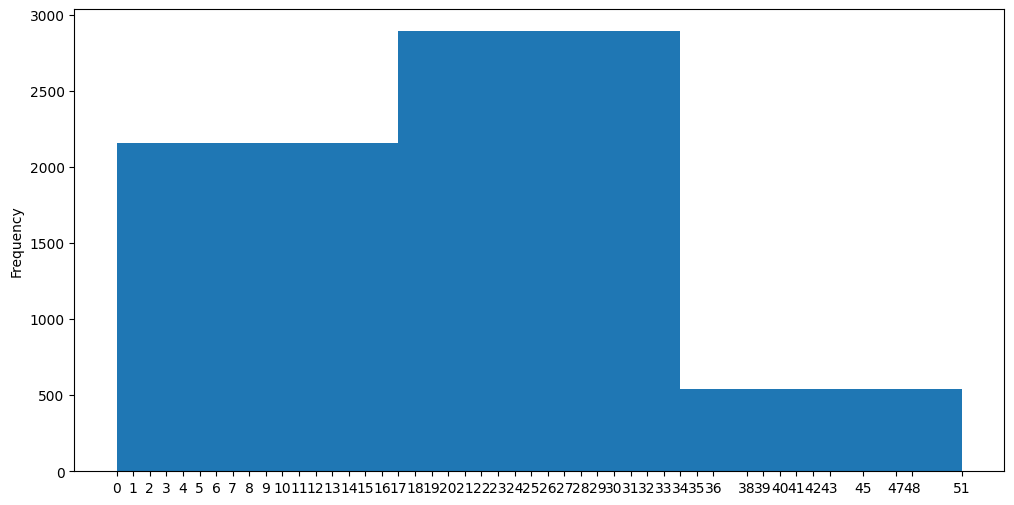

In [97]:
plt.figure(figsize = (12,6))
df['total_floors'].plot(kind= 'hist' , bins = 3)
plt.xticks(ticks = df['total_floors'].unique())
plt.show()

In [98]:
def categorise_floor(row):
    if row['floor_num'] < row['total_floors']*0.3:
        return('lower-floor')
    if row['floor_num'] < row['total_floors']*0.6:
        return('middle-floor') 
    else:
        return('high-floor')
df['floor'] = df.apply(categorise_floor,axis=1)

In [99]:
def categorise_total_floor(row):
    if row['total_floors'] < 5:
        return('low-rise')
    if row['total_floors'] < 24:
        return('mid-rise') 
    else:
        return('high-rise')
df['building_type'] = df.apply(categorise_total_floor,axis=1)

<Axes: ylabel='total_floors'>

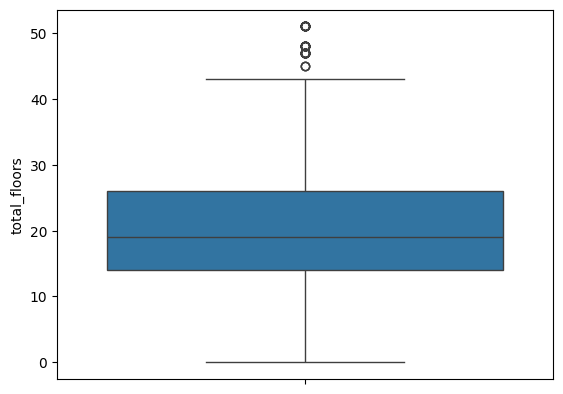

In [100]:
sns.boxplot(df['total_floors'])

In [101]:
df['total_floors'].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

0.10    10.0
0.20    14.0
0.30    14.0
0.40    17.0
0.50    19.0
0.60    21.0
0.70    24.0
0.80    27.0
0.90    33.0
0.95    37.2
0.99    47.0
Name: total_floors, dtype: float64

In [102]:
df.drop(columns=['floor_num','total_floors'],inplace=True)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5589 non-null   object 
 1   price            5589 non-null   float64
 2   super_area       5589 non-null   float64
 3   bedrooms         5589 non-null   int64  
 4   bathroom         5589 non-null   int64  
 5   balcony          5589 non-null   object 
 6   age_possession   5589 non-null   object 
 7   furnishing_type  5589 non-null   object 
 8   facing           5589 non-null   object 
 9   servant_room     5589 non-null   int64  
 10  study_room       5589 non-null   int64  
 11  pooja_room       5589 non-null   int64  
 12  store_room       5589 non-null   int64  
 13  luxury_category  5589 non-null   object 
 14  parking          5589 non-null   int64  
 15  floor            5589 non-null   object 
 16  building_type    5589 non-null   object 
dtypes: float64(2),

## Feature Selection

In [104]:
df_non_feature_selected = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5589 non-null   object 
 1   price            5589 non-null   float64
 2   super_area       5589 non-null   float64
 3   bedrooms         5589 non-null   int64  
 4   bathroom         5589 non-null   int64  
 5   balcony          5589 non-null   object 
 6   age_possession   5589 non-null   object 
 7   furnishing_type  5589 non-null   object 
 8   facing           5589 non-null   object 
 9   servant_room     5589 non-null   int64  
 10  study_room       5589 non-null   int64  
 11  pooja_room       5589 non-null   int64  
 12  store_room       5589 non-null   int64  
 13  luxury_category  5589 non-null   object 
 14  parking          5589 non-null   int64  
 15  floor            5589 non-null   object 
 16  building_type    5589 non-null   object 
dtypes: float64(2),

In [105]:
df_non_feature_selected

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking,floor,building_type
0,sector 39,0.70,1278.0000,2,2,2,1 to 5 year old,Semifurnished,na,0,0,0,1,medium,1,lower-floor,low-rise
1,sohna,0.38,682.3526,2,2,2,1 to 5 year old,Semifurnished,East,0,0,0,0,medium,2,middle-floor,mid-rise
2,sector 71,1.35,1198.0000,2,2,2,10+ year old,Unfurnished,North,0,0,0,0,high,1,lower-floor,mid-rise
3,sector 82,3.40,3240.0000,4,4,2,0 to 1 year old,Furnished,North-East,1,0,1,0,medium,2,high-floor,low-rise
4,sohna,0.95,1065.0000,2,2,2,0 to 1 year old,Semifurnished,na,0,0,0,0,low,1,lower-floor,low-rise
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5584,sohna,0.88,1313.5000,4,4,2,5 to 10 year old,Semifurnished,North,0,0,0,0,medium,2,high-floor,mid-rise
5585,sector 99,3.75,3500.0000,4,4,3+,1 to 5 year old,Unfurnished,North-East,1,1,0,0,high,2,high-floor,mid-rise
5586,sector 92,1.45,1628.0000,3,4,3+,1 to 5 year old,Semifurnished,South-East,1,0,0,0,medium,1,middle-floor,mid-rise
5587,sector 65,3.85,2916.6800,3,3,2,0 to 1 year old,Semifurnished,North,0,0,0,0,medium,0,high-floor,high-rise


In [106]:
#ordinally encoding features [balcony,age_possession,furnishing_type,luxury_category,floor,building_type]
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

category_order = [
    ['0', '1', '2', '3', '3+'],
    ['under construction','0 to 1 year old','1 to 5 year old', '5 to 10 year old','10+ year old' ],
    ['na' , 'Unfurnished','Semifurnished', 'Furnished' ],
    ['low','medium','high'],
    ['lower-floor', 'middle-floor', 'high-floor'],
    ['low-rise', 'mid-rise', 'high-rise']
]
ordinal_cols = [5,6,7,13,15,16]

ordinal_ct = ColumnTransformer(transformers= [('ordinal', OrdinalEncoder(categories=category_order),ordinal_cols)],
                               remainder= 'drop')

encoded_array = ordinal_ct.fit_transform(df)

df[['balcony','age_possession','furnishing_type','luxury_category','floor','building_type']] = encoded_array


In [107]:
#ordinally encoding features [balcony,age_possession,furnishing_type,luxury_category,floor,building_type]

ordinal_ct_2 = ColumnTransformer(transformers= [('ordinal', OrdinalEncoder(),[0,8])],
                               remainder= 'drop')

encoded_array = ordinal_ct_2.fit_transform(df)

df[['sector', 'facing']] = encoded_array


In [108]:
df

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking,floor,building_type
0,34.0,0.70,1278.0000,2,2,2.0,2.0,2.0,8.0,0,0,0,1,1.0,1,0.0,0.0
1,94.0,0.38,682.3526,2,2,2.0,2.0,2.0,0.0,0,0,0,0,1.0,2,1.0,1.0
2,65.0,1.35,1198.0000,2,2,2.0,4.0,1.0,1.0,0,0,0,0,2.0,1,0.0,1.0
3,75.0,3.40,3240.0000,4,4,2.0,1.0,3.0,2.0,1,0,1,0,1.0,2,2.0,0.0
4,94.0,0.95,1065.0000,2,2,2.0,1.0,2.0,8.0,0,0,0,0,0.0,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5584,94.0,0.88,1313.5000,4,4,2.0,3.0,2.0,1.0,0,0,0,0,1.0,2,2.0,1.0
5585,91.0,3.75,3500.0000,4,4,4.0,2.0,1.0,2.0,1,1,0,0,2.0,2,2.0,1.0
5586,87.0,1.45,1628.0000,3,4,4.0,2.0,2.0,5.0,1,0,0,0,1.0,1,1.0,1.0
5587,57.0,3.85,2916.6800,3,3,2.0,1.0,2.0,1.0,0,0,0,0,1.0,0,2.0,2.0


In [109]:
X = df.drop(columns = ['price'])
Y = df['price']

### 0. Correlation coeff

<Axes: >

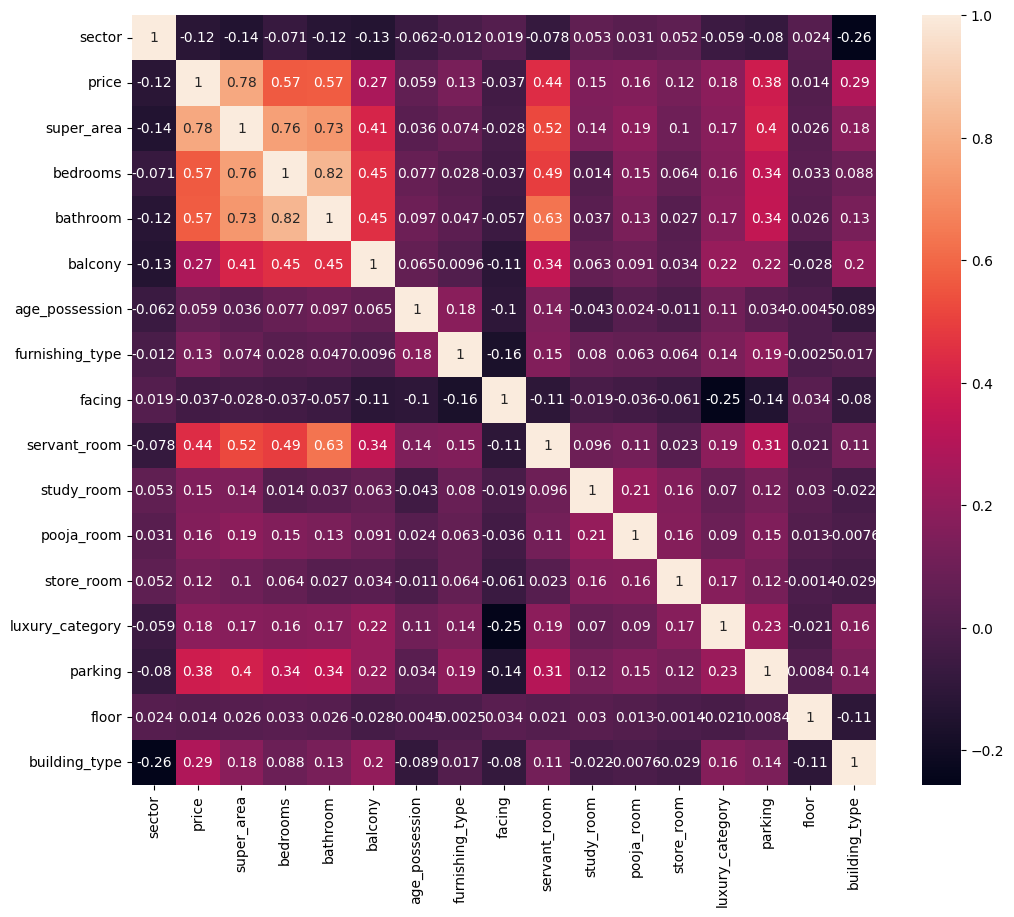

In [110]:
plt.figure(figsize= (12,10))
sns.heatmap(df.corr(),annot=True)

In [111]:
corr_fi = df.corr()['price'].sort_values(ascending=False).to_frame().iloc[1:].reset_index().rename(columns = {'index':'feature','price':'corr_coeff'})
corr_fi

,feature,corr_coeff
0,super_area,0.780121
1,bathroom,0.569967
2,bedrooms,0.567990
3,servant_room,0.440613
4,parking,0.377026
5,building_type,0.285791
6,balcony,0.270289
7,luxury_category,0.184115
8,pooja_room,0.159659
9,study_room,0.150715


### 1. Random Forest Feature importance

In [112]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X,Y)

#extracting feature importance
rf_fi = pd.DataFrame( {
    'feature': X.columns,
    'rf_importance' : rf.feature_importances_
}).sort_values( by = 'rf_importance', ascending = False)

rf_fi

,feature,rf_importance
1,super_area,0.682972
0,sector,0.199365
15,building_type,0.029584
5,age_possession,0.016242
3,bathroom,0.016225
7,facing,0.008560
13,parking,0.008234
2,bedrooms,0.006258
8,servant_room,0.006170
4,balcony,0.005636


### 2. Gradient boosting feature importance

In [113]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X,Y)

#extract feature importance
gb_fi = pd.DataFrame({
    'feature':X.columns,
    'gb_importance': gb.feature_importances_
}).sort_values('gb_importance', ascending=False)

gb_fi

,feature,gb_importance
1,super_area,0.700380
0,sector,0.221107
15,building_type,0.034297
3,bathroom,0.021094
5,age_possession,0.006263
13,parking,0.004957
8,servant_room,0.004846
4,balcony,0.001647
2,bedrooms,0.001498
6,furnishing_type,0.001466


### 3. Permutation Importance

In [114]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size=0.2 , random_state= 42)

#training random forest model on training data
rf = RandomForestRegressor(n_estimators=100)
rf.fit(x_train,y_train)

#calc permutation importance
perm_importance = permutation_importance(rf,x_test,y_test,n_repeats=30)

#visualize
pi_fi = pd.DataFrame({
    'feature':X.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values('permutation_importance',ascending=False)

pi_fi

,feature,permutation_importance
1,super_area,0.886662
0,sector,0.410011
15,building_type,0.074487
3,bathroom,0.015098
2,bedrooms,0.010368
5,age_possession,0.008163
8,servant_room,0.007152
4,balcony,0.002670
10,pooja_room,0.002251
13,parking,0.001419


### 4.Recursive Feature Elemination (RFE) 

In [115]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X.shape[1], step=1)
selector_label = selector_label.fit(X, Y)

# Get the selected features based on RFE
selected_features = X.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
rfe_fi = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

rfe_fi


,feature,rfe_score
1,super_area,0.680508
0,sector,0.204222
15,building_type,0.031680
5,age_possession,0.015581
3,bathroom,0.015011
7,facing,0.008376
13,parking,0.007071
2,bedrooms,0.006755
8,servant_room,0.006147
4,balcony,0.005538


In [116]:
final_fi_df = corr_fi.merge(rf_fi, on= 'feature').merge(gb_fi, on = 'feature').merge(pi_fi,on = 'feature').merge(rfe_fi, on= 'feature').set_index('feature')

In [117]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,rfe_score
feature,,,,,
super_area,0.780121,0.682972,0.700380,0.886662,0.680508
bathroom,0.569967,0.016225,0.021094,0.015098,0.015011
bedrooms,0.567990,0.006258,0.001498,0.010368,0.006755
servant_room,0.440613,0.006170,0.004846,0.007152,0.006147
parking,0.377026,0.008234,0.004957,0.001419,0.007071
building_type,0.285791,0.029584,0.034297,0.074487,0.031680
balcony,0.270289,0.005636,0.001647,0.002670,0.005538
luxury_category,0.184115,0.003607,0.000954,0.001044,0.003578
pooja_room,0.159659,0.002851,0.000005,0.002251,0.002175


In [118]:
ranked_df = final_fi_df.iloc[:,1:].rank(ascending=False, method = 'min')
ranked_df['average_rank'] = ranked_df.mean(axis=1)
ranked_df.sort_values('average_rank', ascending=True).reset_index()

,feature,rf_importance,gb_importance,permutation_importance,rfe_score,average_rank
0,super_area,1.0,1.0,1.0,1.0,1.00
1,sector,2.0,2.0,2.0,2.0,2.00
2,building_type,3.0,3.0,3.0,3.0,3.00
3,bathroom,5.0,4.0,4.0,5.0,4.50
4,age_possession,4.0,5.0,6.0,4.0,4.75
5,bedrooms,8.0,9.0,5.0,8.0,7.50
6,parking,7.0,6.0,10.0,7.0,7.50
7,servant_room,9.0,7.0,7.0,9.0,8.00
8,balcony,10.0,8.0,8.0,10.0,9.00
9,facing,6.0,14.0,16.0,6.0,10.50


In [119]:
['facing','floor','store_room','furnishing_type','study_room','pooja_room']

['facing',
 'floor',
 'store_room',
 'furnishing_type',
 'study_room',
 'pooja_room']

In [120]:
#normalise each value
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [121]:
final_fi_df.mean(axis=1).sort_values(ascending=False)

feature
super_area         0.577149
sector             0.176707
building_type      0.044072
bathroom           0.041449
bedrooms           0.033119
servant_room       0.026747
parking            0.023340
balcony            0.016625
age_possession     0.011751
luxury_category    0.011096
pooja_room         0.009406
study_room         0.009368
furnishing_type    0.008334
store_room         0.006727
floor              0.002886
facing             0.001222
dtype: float64

##### Observation
- Looking at this data, it seems that the columns ['facing','floor','store_room','furnishing_type','study_room','pooja_room'] have the least feature importances
- Need to investigate the impact of dropping these columns on the r2 score

### Making testing model

In [122]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
rf = RandomForestRegressor(n_estimators=100 , random_state=42)

scores = cross_val_score(estimator=rf, X=X, y= Y, cv=5 , scoring= 'r2')

In [123]:
X

,sector,super_area,bedrooms,bathroom,balcony,age_possession,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking,floor,building_type
0,34.0,1278.0000,2,2,2.0,2.0,2.0,8.0,0,0,0,1,1.0,1,0.0,0.0
1,94.0,682.3526,2,2,2.0,2.0,2.0,0.0,0,0,0,0,1.0,2,1.0,1.0
2,65.0,1198.0000,2,2,2.0,4.0,1.0,1.0,0,0,0,0,2.0,1,0.0,1.0
3,75.0,3240.0000,4,4,2.0,1.0,3.0,2.0,1,0,1,0,1.0,2,2.0,0.0
4,94.0,1065.0000,2,2,2.0,1.0,2.0,8.0,0,0,0,0,0.0,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5584,94.0,1313.5000,4,4,2.0,3.0,2.0,1.0,0,0,0,0,1.0,2,2.0,1.0
5585,91.0,3500.0000,4,4,4.0,2.0,1.0,2.0,1,1,0,0,2.0,2,2.0,1.0
5586,87.0,1628.0000,3,4,4.0,2.0,2.0,5.0,1,0,0,0,1.0,1,1.0,1.0
5587,57.0,2916.6800,3,3,2.0,1.0,2.0,1.0,0,0,0,0,1.0,0,2.0,2.0


In [124]:
scores.mean()

0.8774740181911834

In [125]:
#checking after dropping less important columns ['facing','floor','store_room','furnishing_type','study_room']
X_temp = X.drop(columns = ['facing','floor','store_room','furnishing_type','study_room','pooja_room']) 

rf = RandomForestRegressor(n_estimators= 100 ,random_state=42)
scores = cross_val_score(estimator=rf, X=X_temp, y= Y, cv=5 , scoring= 'r2')

scores.mean()

0.8824410895431749

- The columns can be dropped

In [126]:
df_selected = df.drop(columns = ['facing','floor','store_room','furnishing_type','study_room','pooja_room'])

In [127]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5589 non-null   float64
 1   price            5589 non-null   float64
 2   super_area       5589 non-null   float64
 3   bedrooms         5589 non-null   int64  
 4   bathroom         5589 non-null   int64  
 5   balcony          5589 non-null   float64
 6   age_possession   5589 non-null   float64
 7   servant_room     5589 non-null   int64  
 8   luxury_category  5589 non-null   float64
 9   parking          5589 non-null   int64  
 10  building_type    5589 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 480.4 KB


### Building baseline model

In [128]:
df_selected

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,servant_room,luxury_category,parking,building_type
0,34.0,0.70,1278.0000,2,2,2.0,2.0,0,1.0,1,0.0
1,94.0,0.38,682.3526,2,2,2.0,2.0,0,1.0,2,1.0
2,65.0,1.35,1198.0000,2,2,2.0,4.0,0,2.0,1,1.0
3,75.0,3.40,3240.0000,4,4,2.0,1.0,1,1.0,2,0.0
4,94.0,0.95,1065.0000,2,2,2.0,1.0,0,0.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5584,94.0,0.88,1313.5000,4,4,2.0,3.0,0,1.0,2,1.0
5585,91.0,3.75,3500.0000,4,4,4.0,2.0,1,2.0,2,1.0
5586,87.0,1.45,1628.0000,3,4,4.0,2.0,1,1.0,1,1.0
5587,57.0,3.85,2916.6800,3,3,2.0,1.0,0,1.0,0,2.0


In [129]:
X = df_selected.drop(columns=['price'])
Y = df_selected['price']

In [130]:
Y_transformed = np.log1p(Y)

In [131]:
from sklearn.model_selection import KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

In [132]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),['super_area','bedrooms','bathroom','servant_room','parking']),
        ('onehot', OneHotEncoder(handle_unknown = 'infrequent_if_exist'),['sector'])
    ],
    remainder='passthrough'
)

In [133]:
#creating pipeline
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', SVR(kernel='rbf')) 
])

In [134]:
#k fold cross validation
kfold = KFold(n_splits=10,shuffle=True, random_state=42)
scores = cross_val_score(pipeline,X,Y_transformed,cv = kfold , scoring='r2')


In [135]:
scores.mean()

0.9224629494225141

In [136]:
x_train,x_test, y_train, y_test = train_test_split(X,Y_transformed, test_size=0.2)

In [137]:
pipeline.fit(x_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', StandardScaler(),
                                                  ['super_area', 'bedrooms',
                                                   'bathroom', 'servant_room',
                                                   'parking']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['sector'])])),
                ('regressor', SVR())])

In [138]:
y_pred = pipeline.predict(x_test)
y_pred = np.expm1(y_pred)

In [139]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(np.expm1(y_test),y_pred)

0.38634222422741543

### 
- Based on the above tests -> columns can be dropped

In [140]:
df_selected.columns

Index(['sector', 'price', 'super_area', 'bedrooms', 'bathroom', 'balcony',
       'age_possession', 'servant_room', 'luxury_category', 'parking',
       'building_type'],
      dtype='object')

In [141]:
df_non_feature_selected[['sector', 'price', 'super_area', 'bedrooms', 'bathroom', 'balcony',
       'age_possession', 'servant_room', 'luxury_category', 'parking',
       'building_type']].to_csv('4.6_dataset_feature_selected.csv', index= False)